# DF3 – Vendedores y popularidad (Olist)

**Objetivo:** analizar el catálogo por vendedor y la frecuencia con que se vende cada producto, identificando qué vendedores concentran la actividad.

**Grano del dataframe:** una fila = un par vendedor-producto, con las unidades vendidas.

**Origen:** consulta SQL final (`01_df3_consulta_final.sql`) exportada a `df3_vendedores_productos.csv`.

## 1. Carga de datos

In [ ]:
import pandas as pd
df = pd.read_csv("../data/df3_vendedores_productos.csv")

print(df.shape)
df.head()

Se carga el CSV exportado desde MySQL con la consulta final. Cada fila es un par vendedor-producto con las unidades vendidas. Se comprueba que el tamaño es el esperado: 34.448 filas y 6 columnas.

## 2. Revisión de calidad de los datos

In [10]:
df.info()
print("Nulos por columna:")
print(df.isnull().sum())
print("Filas duplicadas:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34448 entries, 0 to 34447
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   seller_id              34448 non-null  object
 1   seller_city            34448 non-null  object
 2   seller_state           34448 non-null  object
 3   product_id             34448 non-null  object
 4   product_category_name  34448 non-null  object
 5   unidades_vendidas      34448 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 1.6+ MB
Nulos por columna:
seller_id                0
seller_city              0
seller_state             0
product_id               0
product_category_name    0
unidades_vendidas        0
dtype: int64
Filas duplicadas: 0


No hay nulos (las categorías vacías se rellenaron con 'sin_categoria' en SQL)

## 3. Ranking de vendedores

In [11]:
ranking = (df.groupby("seller_id")["unidades_vendidas"]
             .sum()
             .sort_values(ascending=False))

print(ranking.head(10))
print("Vendedores en total:", ranking.shape[0])
print("Unidades vendidas en total:", ranking.sum())

seller_id
6560211a19b47992c3666cc44a7e94c0    2033
4a3ca9315b744ce9f8e9374361493884    1987
1f50f920176fa81dab994f9023523100    1931
cc419e0650a3c5ba77189a1882b7556a    1775
da8622b14eb17ae2831f4ac5b9dab84a    1551
955fee9216a65b617aa5c0531780ce60    1499
1025f0e2d44d7041d6cf58b6550e0bfa    1428
7c67e1448b00f6e969d365cea6b010ab    1364
ea8482cd71df3c1969d7b9473ff13abc    1203
7a67c85e85bb2ce8582c35f2203ad736    1171
Name: unidades_vendidas, dtype: int64
Vendedores en total: 3095
Unidades vendidas en total: 112650


Se suman las unidades vendidas por vendedor y se ordenan de mayor a menor. Hay 3.095 vendedores y 112.650 unidades en total, la misma cifra que filas tiene order_items en la base de datos, lo que confirma que no se perdió información en el proceso.

## 4. Porcentaje de ventas de los 10 primeros vendedores

In [12]:
parte = ranking.head(10).sum()
total = ranking.sum()
porcentaje = parte / total * 100
print("Los 1o primeros suman:", round(porcentaje, 1), "% de las unidades vendidas.")

Los 1o primeros suman: 14.2 % de las unidades vendidas.


In [13]:
print("Unidades vendidas por los 10 primeros:", parte, "unidades")

Unidades vendidas por los 10 primeros: 15942 unidades


Se calcula qué parte del total de unidades vendidas suman los 10 vendedores con más ventas: 15.942 unidades, el 14,2 % del total.

## 5. Gráfica del top 10

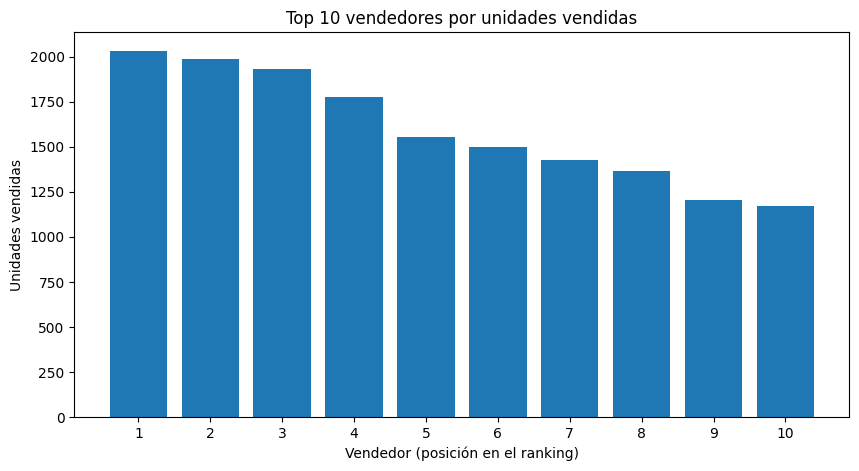

In [14]:
import matplotlib.pyplot as plt

top10 = ranking.head(10)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), top10.values)
plt.xlabel("Vendedor (posición en el ranking)")
plt.ylabel("Unidades vendidas")
plt.title("Top 10 vendedores por unidades vendidas")
plt.xticks(range(1, 11))
plt.show()

Gráfica de barras con las unidades vendidas por los 10 primeros vendedores. Se usa la posición en el ranking en el eje horizontal porque los identificadores de vendedor son códigos demasiado largos para mostrarlos.

## 6. Conclusión

- Los 10 vendedores con más ventas suman 15.942 unidades, el 14,2 % de las 112.650 unidades vendidas. Son el 0,3 % de los 3.095 vendedores.
- El vendedor n.º 1 vendió 2.033 unidades y el n.º 10, 1.171; la diferencia es de 862 unidades.
- La gráfica muestra que la cantidad de ventas baja de forma escalonada y sin mucha dispersión entre los 10 primeros: ninguno domina claramente sobre los demás.
- Lectura: hay una concentración alta en relación con el tamaño del grupo, porque el 0,3 % de los vendedores genera el 14,2 % de las ventas (15.942 unidades). Aun así, el 85,8 % restante se reparte entre los otros 3.085 vendedores.